# Pneumonia Clinical Model Training Notebook

This notebook trains a **Pneumonia Clinical Machine Learning Model** using only the required clinical parameters:

- Fever
- Cough
- Chest Pain
- WBC Count
- SpO₂ / Oxygen Saturation
- Respiratory Symptom / Shortness of Breath

The notebook performs data cleaning, encoding, missing value handling, model training, model comparison, best model evaluation, feature importance, and saves the final model files for deployment.

In [1]:
# ==============================
# Cell 1: Install Required Libraries
# ==============================

!pip install catboost lightgbm xgboost -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==============================
# Cell 2: Import Libraries
# ==============================

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==============================
# Cell 3: Dataset Path Definition
# ==============================
import os
DATASET_PATH = os.path.join("..", "Datasets", "pneumonia_dataset.csv")
print("Using local file:", DATASET_PATH)

Using local file: ..\Datasets\pneumonia_dataset.csv


In [4]:
# ==============================
# Cell 4: Load Dataset
# ==============================

df = pd.read_csv(DATASET_PATH)

print("Dataset Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (710, 16)
Columns:
['PatientID', 'Gender', 'Age', 'Cough', 'Fever', 'Shortness_of_breath', 'Chest_pain', 'Fatigue', 'Confusion', 'Oxygen_saturation', 'Crackles', 'Xray', 'WBC_count', 'Sputum_color', 'Temperature', 'Diagnosis']


,PatientID,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Xray,WBC_count,Sputum_color,Temperature,Diagnosis
0,PNEU4091,M,3,Bloody,High,Mild,Mild,NaN,No,92,Yes,-,-,-,39.7,Yes
1,PNEU6231,M,3,Dry,NaN,NaN,NaN,Mild,-,-,Yes,-,-,Clear,37.0,No
2,PNEU6486,M,3,Dry,NaN,NaN,NaN,Mild,No,99,No,-,-,-,38.0,No
3,PNEU7601,F,3,NaN,Low,Severe,NaN,Moderate,No,99,Yes,-,-,Clear,40.9,Yes
4,PNEU8471,F,3,NaN,High,Moderate,Severe,Mild,-,91,No,-,-,Green,38.1,Yes


In [5]:
# ==============================
# Cell 5: Select Only Required Clinical Parameters
# ==============================

required_columns = [
    "Fever",
    "Cough",
    "Chest_pain",
    "WBC_count",
    "Oxygen_saturation",
    "Shortness_of_breath",
    "Diagnosis"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"These required columns are missing from the dataset: {missing_columns}")

df = df[required_columns].copy()

print("Selected clinical columns:")
print(df.columns.tolist())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

display(df.head())

Selected clinical columns:
['Fever', 'Cough', 'Chest_pain', 'WBC_count', 'Oxygen_saturation', 'Shortness_of_breath', 'Diagnosis']

Missing values before cleaning:
Fever                  310
Cough                  312
Chest_pain             343
WBC_count                0
Oxygen_saturation        0
Shortness_of_breath    317
Diagnosis                0
dtype: int64


,Fever,Cough,Chest_pain,WBC_count,Oxygen_saturation,Shortness_of_breath,Diagnosis
0,High,Bloody,Mild,-,92,Mild,Yes
1,NaN,Dry,NaN,-,-,NaN,No
2,NaN,Dry,NaN,-,99,NaN,No
3,Low,NaN,NaN,-,99,Severe,Yes
4,High,NaN,Severe,-,91,Moderate,Yes


In [6]:
# ==============================
# Cell 6: Clean Invalid Values and Rename Columns
# ==============================

# Replace common invalid symbols with missing values
df = df.replace(["-", "", " ", "NA", "N/A", "nan", "None"], np.nan)

# Rename columns for cleaner model input
df = df.rename(columns={
    "Chest_pain": "ChestPain",
    "WBC_count": "WBCCount",
    "Oxygen_saturation": "SpO2",
    "Shortness_of_breath": "RespiratorySymptom"
})

print("Columns after renaming:")
print(df.columns.tolist())

print("\nMissing values after replacing invalid values:")
print(df.isnull().sum())

display(df.head())

Columns after renaming:
['Fever', 'Cough', 'ChestPain', 'WBCCount', 'SpO2', 'RespiratorySymptom', 'Diagnosis']

Missing values after replacing invalid values:
Fever                 310
Cough                 312
ChestPain             343
WBCCount              700
SpO2                   60
RespiratorySymptom    317
Diagnosis               0
dtype: int64


,Fever,Cough,ChestPain,WBCCount,SpO2,RespiratorySymptom,Diagnosis
0,High,Bloody,Mild,NaN,92,Mild,Yes
1,NaN,Dry,NaN,NaN,NaN,NaN,No
2,NaN,Dry,NaN,NaN,99,NaN,No
3,Low,NaN,NaN,NaN,99,Severe,Yes
4,High,NaN,Severe,NaN,91,Moderate,Yes


In [7]:
# ==============================
# Cell 7: Encode Clinical Categories
# ==============================

# These encodings preserve clinical severity order.
# Fever/ChestPain/RespiratorySymptom: Low/Mild=1, Moderate=2, High/Severe=3
# Cough: Dry=1, Wet=2, Bloody=3
# Diagnosis: No=0, Yes=1

encoding_maps = {
    "Fever": {
        "Low": 1, "low": 1,
        "Moderate": 2, "moderate": 2,
        "High": 3, "high": 3
    },
    "Cough": {
        "Dry": 1, "dry": 1,
        "Wet": 2, "wet": 2,
        "Bloody": 3, "bloody": 3
    },
    "ChestPain": {
        "Mild": 1, "mild": 1,
        "Moderate": 2, "moderate": 2,
        "Severe": 3, "severe": 3
    },
    "RespiratorySymptom": {
        "Mild": 1, "mild": 1,
        "Moderate": 2, "moderate": 2,
        "Severe": 3, "severe": 3
    },
    "Diagnosis": {
        "No": 0, "no": 0, "Normal": 0, "normal": 0, 0: 0, "0": 0,
        "Yes": 1, "yes": 1, "Pneumonia": 1, "pneumonia": 1, 1: 1, "1": 1
    }
}

for col, mapping in encoding_maps.items():
    df[col] = df[col].map(mapping)

# Convert numeric columns safely
df["WBCCount"] = pd.to_numeric(df["WBCCount"], errors="coerce")
df["SpO2"] = pd.to_numeric(df["SpO2"], errors="coerce")

# Diagnosis is essential, so rows with missing target must be removed
df = df.dropna(subset=["Diagnosis"]).copy()
df["Diagnosis"] = df["Diagnosis"].astype(int)

print("Encoded dataset preview:")
display(df.head())

print("\nMissing values after encoding:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Diagnosis"].value_counts())

Encoded dataset preview:


,Fever,Cough,ChestPain,WBCCount,SpO2,RespiratorySymptom,Diagnosis
0,3.0,3.0,1.0,NaN,92.0,1.0,1
1,NaN,1.0,NaN,NaN,NaN,NaN,0
2,NaN,1.0,NaN,NaN,99.0,NaN,0
3,1.0,NaN,NaN,NaN,99.0,3.0,1
4,3.0,NaN,3.0,NaN,91.0,2.0,1



Missing values after encoding:
Fever                 310
Cough                 312
ChestPain             343
WBCCount              700
SpO2                   60
RespiratorySymptom    317
Diagnosis               0
dtype: int64

Target distribution:
Diagnosis
1    408
0    302
Name: count, dtype: int64


In [8]:
# ==============================
# Cell 8: Feature and Target Selection
# ==============================

features = [
    "Fever",
    "Cough",
    "ChestPain",
    "WBCCount",
    "SpO2",
    "RespiratorySymptom"
]

target = "Diagnosis"

X = df[features].copy()
y = df[target].copy()

print("Final Features Used for Pneumonia Clinical Model:")
print(features)

print("\nFeature dtypes:")
print(X.dtypes)

print("\nTarget distribution:")
print(y.value_counts())

Final Features Used for Pneumonia Clinical Model:
['Fever', 'Cough', 'ChestPain', 'WBCCount', 'SpO2', 'RespiratorySymptom']

Feature dtypes:
Fever                 float64
Cough                 float64
ChestPain             float64
WBCCount              float64
SpO2                  float64
RespiratorySymptom    float64
dtype: object

Target distribution:
Diagnosis
1    408
0    302
Name: count, dtype: int64


In [9]:
# ==============================
# Cell 9: Safe Missing Value Handling
# ==============================

# Categorical symptom values are filled using mode.
# Numeric values are filled using median.

categorical_features = [
    "Fever",
    "Cough",
    "ChestPain",
    "RespiratorySymptom"
]

numeric_features = [
    "WBCCount",
    "SpO2"
]

print("Before imputation:")
print(X.isnull().sum())

imputation_values = {}

for col in categorical_features:
    mode_value = X[col].mode(dropna=True)
    fill_value = mode_value[0] if len(mode_value) > 0 else 0
    X[col] = X[col].fillna(fill_value)
    imputation_values[col] = fill_value

for col in numeric_features:
    median_value = X[col].median()
    fill_value = median_value if not pd.isna(median_value) else 0
    X[col] = X[col].fillna(fill_value)
    imputation_values[col] = fill_value

print("\nAfter imputation:")
print(X.isnull().sum())

print("\nImputation values used:")
print(imputation_values)

display(X.head())

Before imputation:
Fever                 310
Cough                 312
ChestPain             343
WBCCount              700
SpO2                   60
RespiratorySymptom    317
dtype: int64

After imputation:
Fever                 0
Cough                 0
ChestPain             0
WBCCount              0
SpO2                  0
RespiratorySymptom    0
dtype: int64

Imputation values used:
{'Fever': 1.0, 'Cough': 1.0, 'ChestPain': 1.0, 'RespiratorySymptom': 1.0, 'WBCCount': 9801.5, 'SpO2': 93.0}


,Fever,Cough,ChestPain,WBCCount,SpO2,RespiratorySymptom
0,3.0,3.0,1.0,9801.5,92.0,1.0
1,1.0,1.0,1.0,9801.5,93.0,1.0
2,1.0,1.0,1.0,9801.5,99.0,1.0
3,1.0,1.0,1.0,9801.5,99.0,3.0
4,3.0,1.0,3.0,9801.5,91.0,2.0


In [10]:
# ==============================
# Cell 10: Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: (568, 6)
Testing samples : (142, 6)

Training class distribution:
Diagnosis
1    326
0    242
Name: count, dtype: int64

Testing class distribution:
Diagnosis
1    82
0    60
Name: count, dtype: int64


In [11]:
# ==============================
# Cell 11: Feature Scaling
# ==============================

# Scaling is mainly required for Logistic Regression and SVM.
# Tree-based models will use the unscaled features.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [12]:
# ==============================
# Cell 12: Define ML Models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=8,
        loss_function="Logloss",
        verbose=0,
        random_seed=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=8,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
}

print("Total models defined:", len(models))
print(list(models.keys()))

Total models defined: 8
['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Support Vector Machine', 'XGBoost', 'CatBoost', 'LightGBM']


In [13]:
# ==============================
# Cell 13: Train Models and Create Comparison Table
# ==============================

results = {}
trained_predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name in ["Logistic Regression", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    trained_predictions[name] = {
        "prediction": y_pred,
        "probability": y_prob
    }

    results[name] = {
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred, average="weighted"), 4),
        "Recall": round(recall_score(y_test, y_pred, average="weighted"), 4),
        "F1 Score": round(f1_score(y_test, y_pred, average="weighted"), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    }

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False).reset_index()
comparison_df = comparison_df.rename(columns={"index": "Model"})
comparison_df.insert(0, "Rank", range(1, len(comparison_df) + 1))

print("Model Performance Comparison:")
display(comparison_df)


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...



Training Extra Trees...



Training Support Vector Machine...

Training XGBoost...



Training CatBoost...



Training LightGBM...


Model Performance Comparison:


,Rank,Model,Accuracy (%),Precision,Recall,F1 Score,ROC-AUC
0,1,Decision Tree,97.89,0.9799,0.9789,0.9789,0.9835
1,2,Random Forest,97.89,0.9799,0.9789,0.9789,0.9818
2,3,Extra Trees,97.89,0.9799,0.9789,0.9789,0.9824
3,4,XGBoost,97.89,0.9799,0.9789,0.9789,0.9825
4,5,CatBoost,97.89,0.9799,0.9789,0.9789,0.9839
5,6,LightGBM,97.89,0.9799,0.9789,0.9789,0.9837
6,7,Logistic Regression,97.18,0.9723,0.9718,0.9719,0.9683
7,8,Support Vector Machine,96.48,0.9650,0.9648,0.9648,0.9883


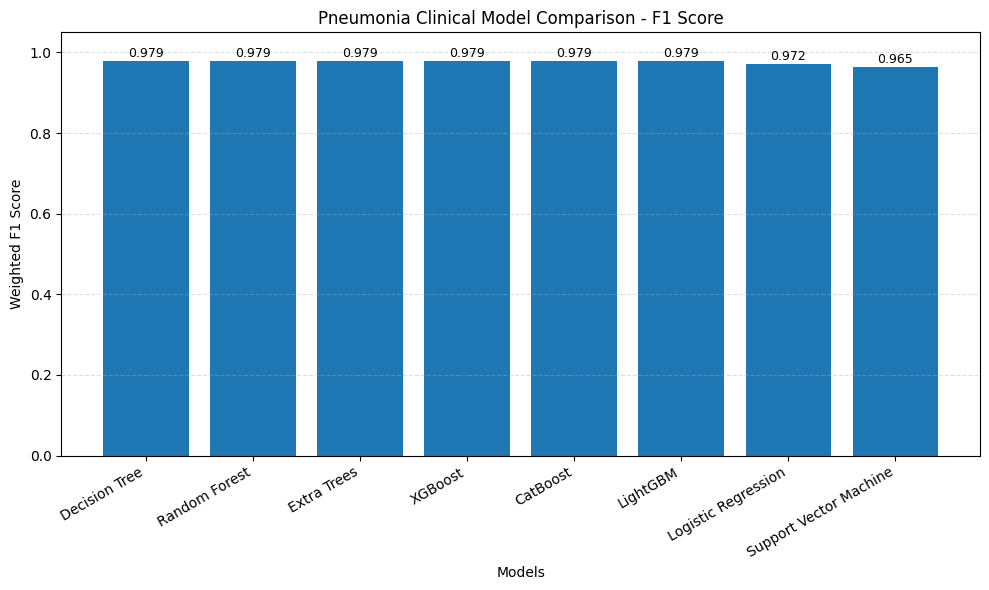

In [14]:
# ==============================
# Cell 14: Visualize Model Comparison
# ==============================

plt.figure(figsize=(10, 6))
plt.bar(comparison_df["Model"], comparison_df["F1 Score"])

plt.title("Pneumonia Clinical Model Comparison - F1 Score")
plt.xlabel("Models")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

for i, v in enumerate(comparison_df["F1 Score"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
# ==============================
# Cell 15: Select and Evaluate Best Model Clearly
# ==============================

best_model_name = comparison_df.loc[0, "Model"]
best_model = models[best_model_name]

y_pred_best = trained_predictions[best_model_name]["prediction"]
y_prob_best = trained_predictions[best_model_name]["probability"]

print("=" * 75)
print(f"BEST PNEUMONIA CLINICAL MODEL: {best_model_name}")
print("=" * 75)

print(f"Accuracy : {accuracy_score(y_test, y_pred_best) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_best, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best, average='weighted'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Pneumonia", "Pneumonia"]
))

BEST PNEUMONIA CLINICAL MODEL: Decision Tree
Accuracy : 97.89%
Precision: 0.9799
Recall   : 0.9789
F1 Score : 0.9789
ROC-AUC  : 0.9835

Classification Report:
              precision    recall  f1-score   support

No Pneumonia       0.95      1.00      0.98        60
   Pneumonia       1.00      0.96      0.98        82

    accuracy                           0.98       142
   macro avg       0.98      0.98      0.98       142
weighted avg       0.98      0.98      0.98       142



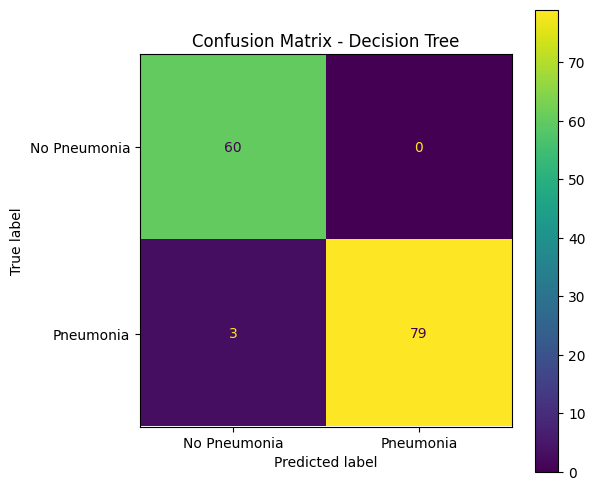

In [16]:
# ==============================
# Cell 16: Confusion Matrix for Best Model
# ==============================

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Pneumonia", "Pneumonia"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()

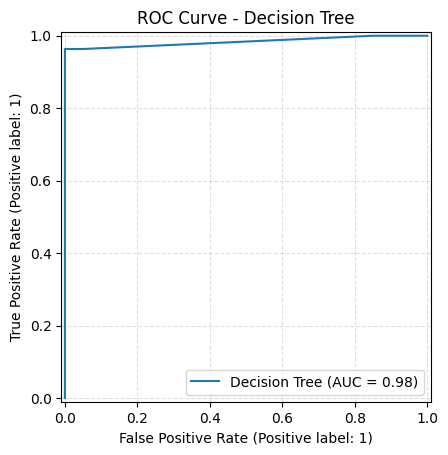

In [17]:
# ==============================
# Cell 17: ROC Curve for Best Model
# ==============================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best,
    name=best_model_name
)

plt.title(f"ROC Curve - {best_model_name}")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Feature Importance:


,Feature,Importance
1,Cough,0.350702
2,ChestPain,0.329574
5,RespiratorySymptom,0.203135
0,Fever,0.105749
4,SpO2,0.010840
3,WBCCount,0.000000


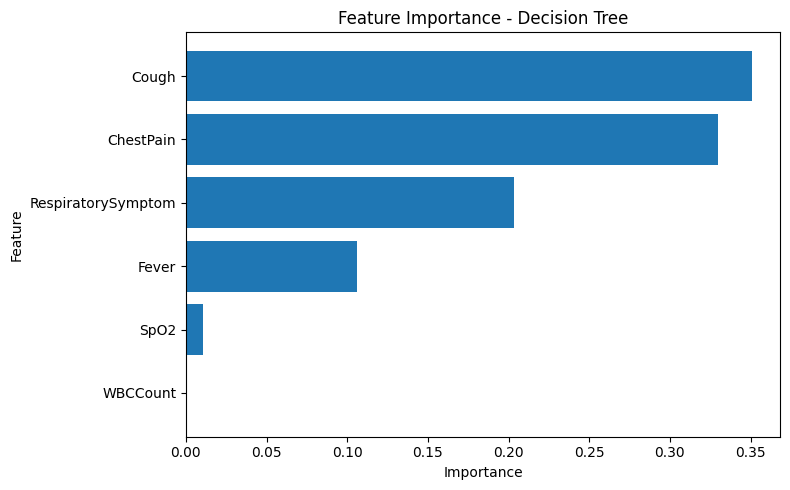

In [18]:
# ==============================
# Cell 18: Feature Importance
# ==============================

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("Feature Importance:")
    display(importance_df)

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print(f"Feature importance is not directly available for {best_model_name}.")
    print("Use tree-based best model such as LightGBM, CatBoost, XGBoost, Random Forest, or Extra Trees for direct feature importance.")

In [19]:
# ==============================
# Cell 19: Cross-Validation for Best Model
# ==============================

# Cross-validation gives a more reliable estimate than a single train-test split.
# For Logistic Regression/SVM, cross-validation is done on scaled features.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_model_name in ["Logistic Regression", "Support Vector Machine"]:
    cv_X = scaler.transform(X)
else:
    cv_X = X

cv_scores = cross_val_score(
    best_model,
    cv_X,
    y,
    cv=skf,
    scoring="f1_weighted"
)

print("5-Fold Cross Validation F1 Scores:")
print(cv_scores)
print(f"Mean F1 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

5-Fold Cross Validation F1 Scores:
[0.985944   0.96493932 0.95096382 0.98594105 0.95788231]
Mean F1 Score: 0.9691
Standard Deviation: 0.0144


In [20]:
# ==============================
# Cell 20: Save Model Artifacts
# ==============================

artifact_bundle = {
    "best_model_name": best_model_name,
    "best_model": best_model,
    "features": features,
    "scaler": scaler,
    "imputation_values": imputation_values,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "class_labels": {0: "No Pneumonia", 1: "Pneumonia"}
}

joblib.dump(best_model, "best_pneumonia_clinical_model.pkl")
joblib.dump(scaler, "pneumonia_scaler.pkl")
joblib.dump(imputation_values, "pneumonia_imputation_values.pkl")
joblib.dump(features, "pneumonia_feature_columns.pkl")
joblib.dump(artifact_bundle, "pneumonia_clinical_model_bundle.pkl")

comparison_df.to_csv("Pneumonia_Clinical_Model_Comparison.csv", index=False)

print("Saved files:")
print("1. best_pneumonia_clinical_model.pkl")
print("2. pneumonia_scaler.pkl")
print("3. pneumonia_imputation_values.pkl")
print("4. pneumonia_feature_columns.pkl")
print("5. pneumonia_clinical_model_bundle.pkl")
print("6. Pneumonia_Clinical_Model_Comparison.csv")

Saved files:
1. best_pneumonia_clinical_model.pkl
2. pneumonia_scaler.pkl
3. pneumonia_imputation_values.pkl
4. pneumonia_feature_columns.pkl
5. pneumonia_clinical_model_bundle.pkl
6. Pneumonia_Clinical_Model_Comparison.csv


In [21]:
# ==============================
# Cell 21: Test Prediction on One Sample
# ==============================

sample = X_test.iloc[[0]].copy()

print("Sample Input:")
display(sample.T)

if best_model_name in ["Logistic Regression", "Support Vector Machine"]:
    sample_input = scaler.transform(sample)
else:
    sample_input = sample

pred = best_model.predict(sample_input)
prob = best_model.predict_proba(sample_input)[0]

label = "Pneumonia" if pred[0] == 1 else "No Pneumonia"

print("\nPredicted Result:", label)
print("\nPrediction Probabilities:")
print(f"No Pneumonia: {prob[0] * 100:.2f}%")
print(f"Pneumonia   : {prob[1] * 100:.2f}%")

Sample Input:


,6
Fever,1.0
Cough,1.0
ChestPain,1.0
WBCCount,9801.5
SpO2,92.0
RespiratorySymptom,1.0



Predicted Result: No Pneumonia

Prediction Probabilities:
No Pneumonia: 93.19%
Pneumonia   : 6.81%


In [22]:
# ==============================
# Cell 22: Custom Patient Prediction Function
# ==============================

def predict_pneumonia_clinical(
    fever,
    cough,
    chest_pain,
    wbc_count,
    spo2,
    respiratory_symptom
):
    """
    Input encoding:
    Fever: Low=1, Moderate=2, High=3
    Cough: Dry=1, Wet=2, Bloody=3
    Chest Pain: Mild=1, Moderate=2, Severe=3
    Respiratory Symptom: Mild=1, Moderate=2, Severe=3
    """

    patient = pd.DataFrame([{
        "Fever": fever,
        "Cough": cough,
        "ChestPain": chest_pain,
        "WBCCount": wbc_count,
        "SpO2": spo2,
        "RespiratorySymptom": respiratory_symptom
    }])

    # Apply same missing value handling
    for col, value in imputation_values.items():
        patient[col] = patient[col].fillna(value)

    patient = patient[features]

    if best_model_name in ["Logistic Regression", "Support Vector Machine"]:
        model_input = scaler.transform(patient)
    else:
        model_input = patient

    pred = best_model.predict(model_input)[0]
    prob = best_model.predict_proba(model_input)[0]

    result = "Pneumonia" if pred == 1 else "No Pneumonia"

    return {
        "Prediction": result,
        "No Pneumonia Probability (%)": round(prob[0] * 100, 2),
        "Pneumonia Probability (%)": round(prob[1] * 100, 2)
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [23]:
# ==============================
# Cell 23: Example Custom Patient Prediction
# ==============================

# Example patient:
# Fever=High, Cough=Dry, ChestPain=Moderate, WBC=11000, SpO2=91, RespiratorySymptom=Severe

result = predict_pneumonia_clinical(
    fever=3,
    cough=1,
    chest_pain=2,
    wbc_count=11000,
    spo2=91,
    respiratory_symptom=3
)

print("Custom Patient Prediction:")
print(result)

Custom Patient Prediction:
{'Prediction': 'Pneumonia', 'No Pneumonia Probability (%)': 0.0, 'Pneumonia Probability (%)': 100.0}


In [24]:
# ==============================
# Cell 24: Download Final Files (Optional)
# ==============================
try:
    from google.colab import files
    files.download("best_pneumonia_clinical_model.pkl")
    files.download("pneumonia_scaler.pkl")
    files.download("pneumonia_imputation_values.pkl")
    files.download("pneumonia_feature_columns.pkl")
    files.download("pneumonia_clinical_model_bundle.pkl")
    files.download("Pneumonia_Clinical_Model_Comparison.csv")
except ImportError:
    print("Saved files locally. (Google Colab files.download skipped)")

Saved files locally. (Google Colab files.download skipped)
